<a href="https://colab.research.google.com/github/AS-236/My_ML_Repo/blob/main/Titanic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [13]:
df=pd.read_csv("Titanic-Dataset.csv")

In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


##EDA

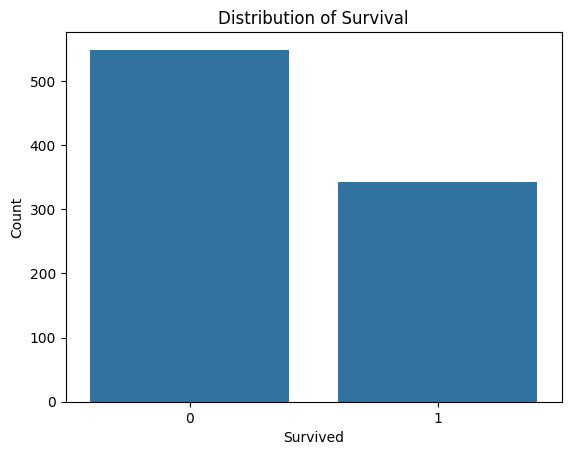

In [17]:
plt.figure()
sns.countplot(x='Survived', data=df)
plt.title('Distribution of Survival')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

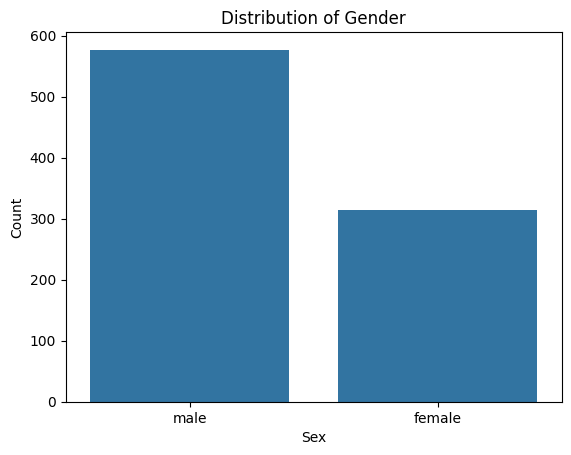

In [18]:
plt.figure()
sns.countplot(x='Sex', data=df)
plt.title('Distribution of Gender')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

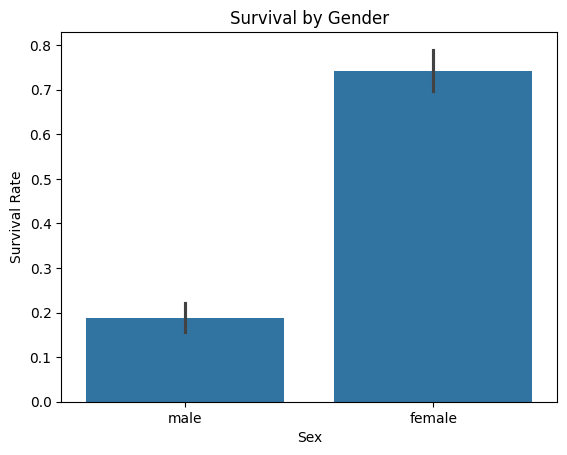

In [19]:
plt.figure()
sns.barplot(x="Sex",y="Survived",data=df)
plt.title("Survival by Gender")
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

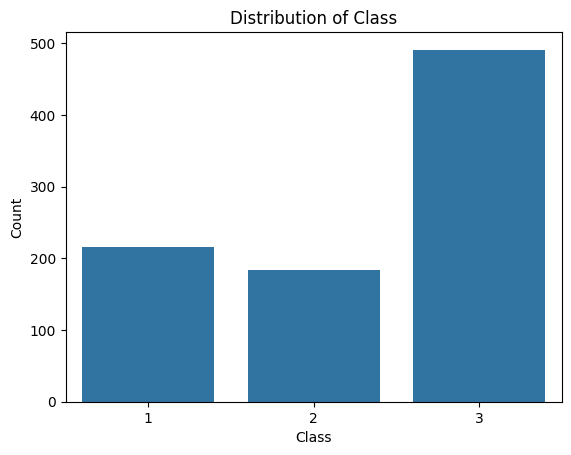

In [20]:
plt.figure()
sns.countplot(x='Pclass', data=df)
plt.title('Distribution of Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

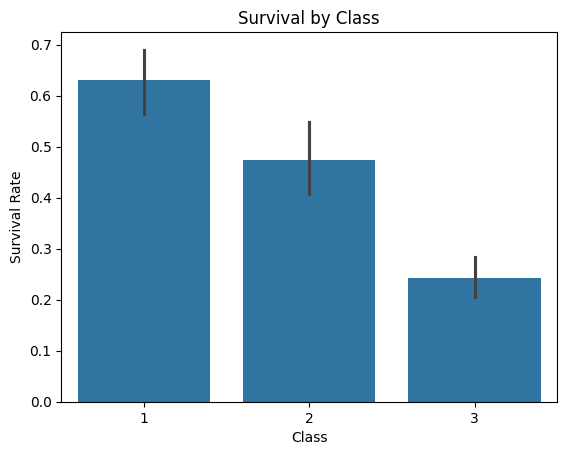

In [21]:
plt.figure()
sns.barplot(x="Pclass",y="Survived",data=df)
plt.title("Survival by Class")
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.show()

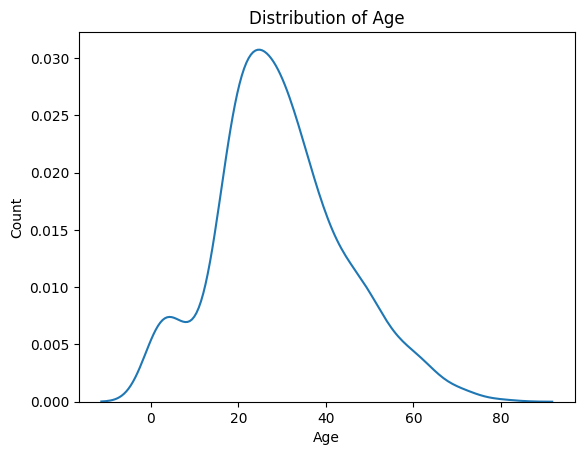

In [22]:
plt.figure()
sns.kdeplot(x='Age', data=df)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

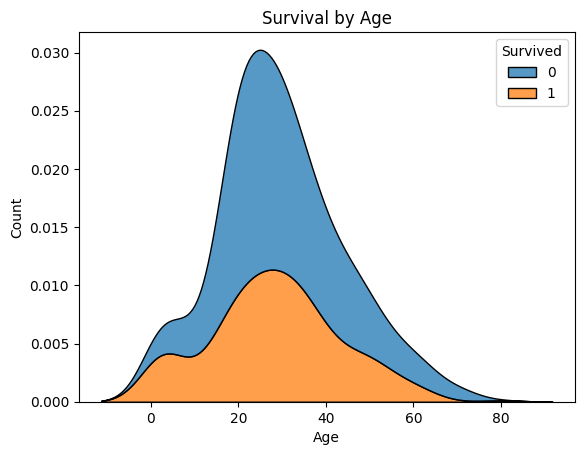

In [23]:
plt.figure()
sns.kdeplot(x='Age', hue='Survived', data=df, multiple='stack')
plt.title('Survival by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

##Data Pre Processing

In [24]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked']

In [25]:
numeric_imputer = SimpleImputer(strategy='median')
numeric_scaler = RobustScaler()

categorical_imputer = SimpleImputer(strategy='most_frequent')
categorical_encoder = OneHotEncoder(drop='first')

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', numeric_imputer),
                                ('scaler', numeric_scaler)]), numeric_features),
        ('cat', Pipeline(steps=[('imputer', categorical_imputer),
                                ('encoder', categorical_encoder)]), categorical_features)
    ],
    remainder='passthrough'
)

In [27]:
X = df.drop(['Survived', 'Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1)
test_data = df.drop(['Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##Model Building

In [28]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes':GaussianNB()
}

In [29]:
results = {}
for name, clf in classifiers.items():
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    Precision = precision_score(y_test, y_pred)
    Recall = recall_score(y_test, y_pred)
    results[name] = {"Accuracy": accuracy, "Precision": Precision,"Recall":Recall}

results_df = pd.DataFrame(results).T
print("Model Performance Comaprison:")
print(results_df)

Model Performance Comaprison:
                     Accuracy  Precision    Recall
Logistic Regression  0.810056   0.785714  0.743243
Random Forest        0.815642   0.836066  0.689189
K-Nearest Neighbors  0.826816   0.802817  0.770270
Decision Tree        0.793296   0.734177  0.783784
Naive Bayes          0.770950   0.720000  0.729730
